###**Proyecto final - Formula 1**

**Integrantes:**

Edwin Leal Guadalajara

Kevin Javier Perez Meza

Diego Alberto Rivera Galván

María Fernanda Sánchez Rentería

Fernanda Lizeth Zambrano Gudiño

**Materias:**

- Complejidad computacional y optimización de soluciones

##**Análisis de Complejidad Big O: KNN Manual vs. Scikit-learn**

Comparativa técnica entre la implementación manual de K-Nearest Neighbors (KNN) y la implementación optimizada de la librería scikit-learn y evaluacion de la eficiencia teórica frente a la ejecución en código real.



##1-Modelo Manual: K-Nearest Neighbors (KNN)   (`knn_dist_euclidea`)

Esta implementación utiliza un enfoque de **fuerza bruta** (búsqueda exhaustiva). Para cada punto de prueba, el algoritmo recorre todo el conjunto de entrenamiento.

### Análisis de Complejidad (Big O) Modelo Manual
Definiendo $N$ como el número de muestras de entrenamiento, $d$ como las características y $M$ como las muestras a predecir:

* **Cálculo de distancias:** (Iterar sobre cada punto y calcular la diferencia matemática) $O(N \cdot d)$.

* **Ordenamiento (Algoritmo Timsort):** $O(N \log N)$

* **Votación (Moda):** $O(k)$

**Complejidad Total de Inferencia:** (Para predecir un solo punto, la complejidad es de $O(N \cdot d + N \log N)$.)

   Para todo el conjunto de prueba $M$, la complejidad se dispara a $O(M(N \cdot d + N \log N))$.

##2-Modelo Optimizado: (`KNeighborsClassifier` de scikit-learn)

Scikit-learn no utiliza fuerza bruta por defecto. Para optimizar las consultas, la librería construye una estructura de datos espacial, típicamente un **KD-Tree** (K-Dimensional Tree) o un **Ball Tree**, que particiona el espacio de características. Además, todas las operaciones de bajo nivel están vectorizadas en C a través de NumPy y Cython.

### Análisis de Complejidad (Big O) Modelo Optimizado
* **Fase de Entrenamiento (Construcción del árbol):** A diferencia del algoritmo manual que tiene un entrenamiento de $O(1)$, construir un KD-Tree toma $O(d \cdot N \log N)$.

* **Fase de Inferencia (Búsqueda):** Al consultar un nuevo punto, el árbol permite descartar grandes porciones del espacio sin calcular sus distancias. La complejidad promedio de búsqueda para un solo punto se reduce a $O(d \log N)$.

**Complejidad Total de Inferencia:** $O(M \cdot d \log N)$.

## Conclusión Comparativa

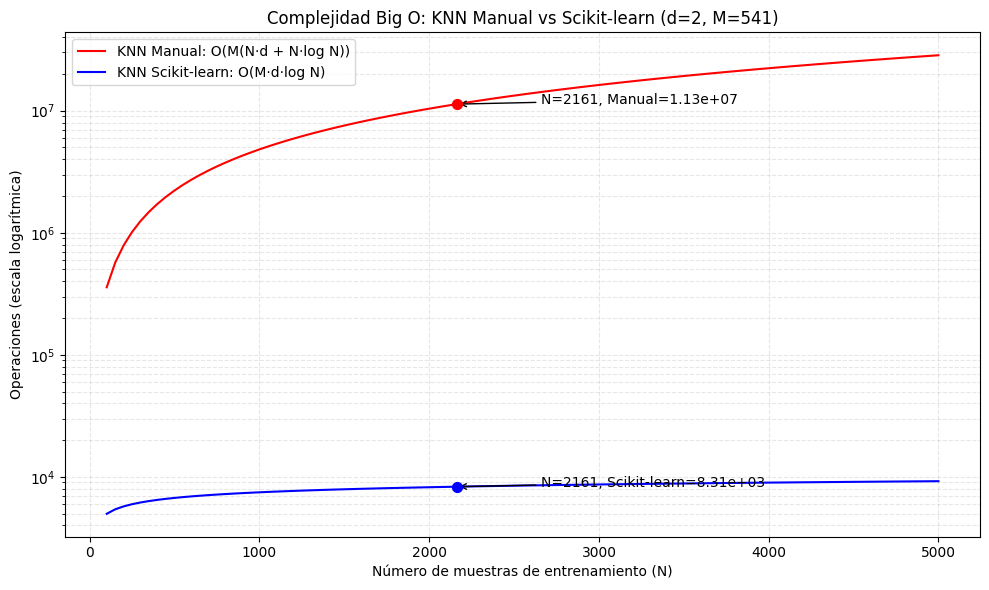

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parámetros fijos
d = 2
M = 541

# Rango de valores para N (incluyendo el valor específico proporcionado)
N_values = np.linspace(100, 5000, 100)

# Cálculo de complejidades
manual_complexity = M * (N_values * d + N_values * np.log(N_values))
sklearn_complexity = M * d * np.log(N_values)

# Configuración de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(N_values, manual_complexity, 'r-', label='KNN Manual: O(M(N·d + N·log N))')
plt.plot(N_values, sklearn_complexity, 'b-', label='KNN Scikit-learn: O(M·d·log N)')

# Puntos específicos con los valores dados
N_given = 2161
manual_point = M * (N_given * d + N_given * np.log(N_given))
sklearn_point = M * d * np.log(N_given)

plt.scatter([N_given], [manual_point], color='red', s=50, zorder=5)
plt.scatter([N_given], [sklearn_point], color='blue', s=50, zorder=5)

# Formato del eje y para mostrar notación científica
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.2e}'))

# Títulos y etiquetas
plt.title('Complejidad Big O: KNN Manual vs Scikit-learn (d=2, M=541)')
plt.xlabel('Número de muestras de entrenamiento (N)')
plt.ylabel('Operaciones (escala logarítmica)')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()

# Anotaciones para los puntos específicos
plt.annotate(f'N={N_given}, Manual={manual_point:.2e}',
             xy=(N_given, manual_point),
             xytext=(N_given+500, manual_point),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f'N={N_given}, Scikit-learn={sklearn_point:.2e}',
             xy=(N_given, sklearn_point),
             xytext=(N_given+500, sklearn_point),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()


| Característica | Modelo Manual | Scikit-Learn |
| :--- | :--- | :--- |
| **Exactitud** | ~65.62% | ~65.62% |
| **Enfoque** | Fuerza Bruta | Estructura Espacial (Árboles) |
| **Escalabilidad** | Baja (Lineal/Log-lineal) | Alta (Logarítmica) |
| **Uso Ideal** | Propósitos Académicos | Entornos de Producción |

Aunque ambos modelos alcanzan la misma precisión (Esto demuestra que la lógica matemática del modelo manual reproduce de forma fiel el concepto geométrico subyacente del algoritmo.), la implementación de la librería scikit-learn es significativamente más eficiente para grandes volúmenes de datos gracias a la reducción de la complejidad de búsqueda de $N$ --> $\log N$.

## **Clasificador de Árbol de Decisión (Decision Tree Classifier - DTC)**

La complejidad de un DTC varía significativamente entre la fase de entrenamiento y la de predicción, y también depende de la profundidad del árbol y el número de características.

*   **Complejidad de Entrenamiento (Construcción del Árbol):**
    *   **Típica:** O(d * n * log(n))
        *  **n:** Número de muestras de entrenamiento.
        *   **d:** Número de características.
        *   **log(n):** Representa la profundidad promedio del árbol y la eficiencia en la búsqueda de los mejores puntos de división. Este log(n) es a menudo resultado de técnicas de optimización (como el pre-ordenamiento de características).
    *   **Peor Caso (sin optimizaciones eficientes):** O(d * n^2)
        *   Esto puede ocurrir si, para cada nodo y cada característica, se necesita iterar sobre **n** muestras para encontrar el mejor split, y si el árbol crece muy profundo y desequilibrado.

*   **Complejidad de Predicción (Clasificación de una Nueva Muestra):**
    *   **Complejidad:** O(D)
        *   **D:** Profundidad del árbol. En un árbol balanceado, **D** es **(log(n))**. En el peor caso **D** puede ser **O(n)**.

#### **Optimización para DTC:**

1.  **Limitar la Profundidad del Árbol (max_depth):** Previene el sobreajuste y reduce tanto el tiempo de entrenamiento como el de predicción. Ya usamos el **max_depth=6**, lo cual es una bueno para nosotros.
2.  **Establecer Mínimo de Muestras por División (min_samples_split):** Requiere un número mínimo de muestras para considerar una división, evitando que el árbol crezca excesivamente en ramas con pocas muestras. Estamos usando **min_samples_split=30**, lo cual nos afecta poquito en esa parte
3.  **Establecer Mínimo de Muestras por Hoja (min_samples_leaf):** Asegurar que cada hoja final tenga un número mínimo de muestras, lo que ayuda a la generalización. Estamos usando **min_samples_leaf=7**, se podria reducir hasta cierto punto
4.  **Podado (Pruning):** Eliminar ramas del árbol que no aportan valor significativo a la predicción, reduciendo la complejidad del modelo, como anteriormente podriamos reducir un poquito las hojas de 30 a 25 y ver como este cambia a bien o a mala prediccion.
5.  **Conjuntos de Características:** Reducir el número de características (d) mediante la selección o extracción de características puede acelerar el entrenamiento, especialmente si se trabaja con muchos datos.

### Gráfico de Comparación Conceptual de Complejidad (Big O)

A continuación, se muestra un gráfico que ilustra cómo escalan las complejidades teóricas para diferentes algoritmos, tomando el número de muestras (`n`) como variable principal. Utilizaremos las siguientes representaciones:

*   **DTC Optimizado (Scikit-learn):** Representado por `O(n log n)`, que es la complejidad típica de entrenamiento para algoritmos eficientes de árboles de decisión.
*   **DTC Naive/Peor Caso (Manual):** Representado por `O(n^2)`, que podría ser la complejidad de entrenamiento en el peor de los casos o para una implementación manual menos optimizada que itera extensamente para encontrar divisiones.

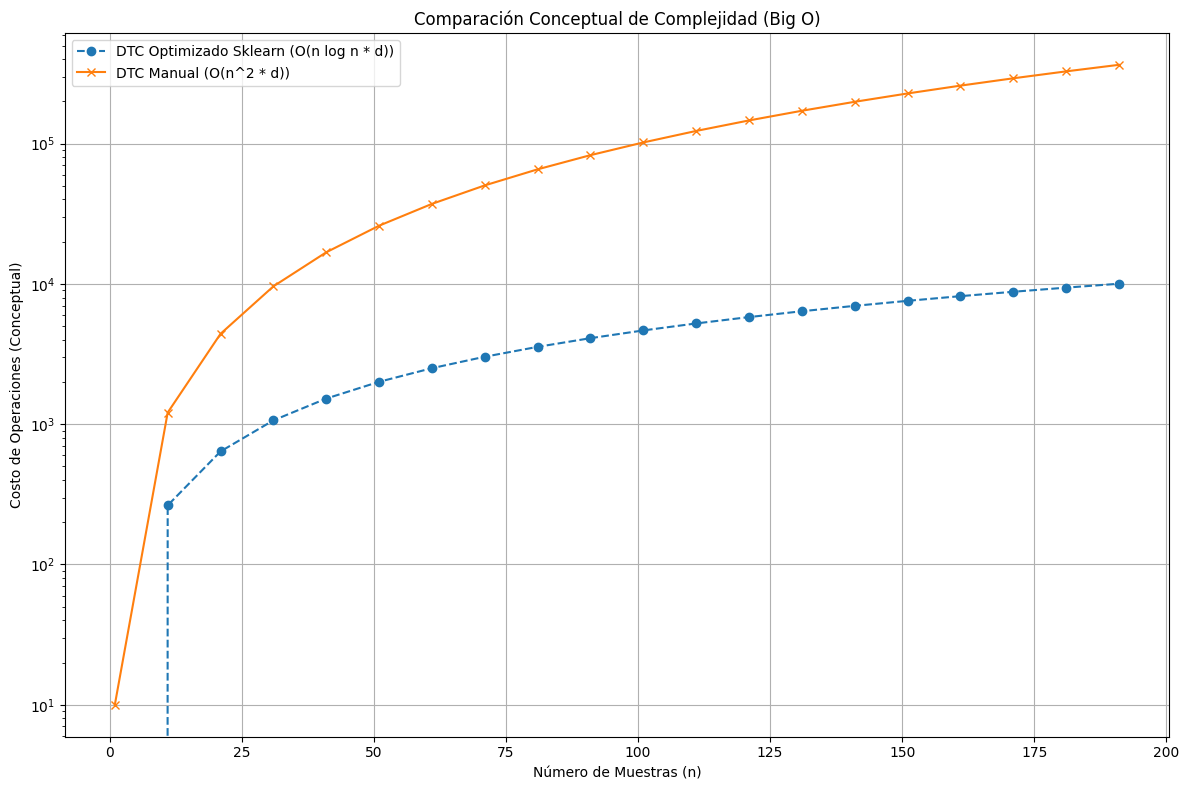

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Usamos un rango pequeño para visualizar la diferencia en crecimiento más claramente
n_values = np.arange(1, 200, 10)

# Número de características (d) - constante para este ejemplo
d = 10

# Complejidad teórica de entrenamiento DTC (optimizado - Scikit-learn)
complexity_dtc_optimized = n_values * np.log(n_values) * d

# Complejidad teórica de entrenamiento DTC (naive / peor caso - manual)
complexity_dtc_naive = n_values**2 * d

plt.figure(figsize=(12, 8))

plt.plot(n_values, complexity_dtc_optimized, label=f'DTC Optimizado Sklearn (O(n log n * d))', marker='o', linestyle='--')
plt.plot(n_values, complexity_dtc_naive, label=f'DTC Manual (O(n^2 * d))', marker='x', linestyle='-')

plt.xlabel('Número de Muestras (n)')
plt.ylabel('Costo de Operaciones (Conceptual)')
plt.title('Comparación Conceptual de Complejidad (Big O)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Usar escala logarítmica en el eje Y para ver mejor las diferencias de crecimiento
plt.tight_layout()
plt.show()